In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm

class ArtifactCNN(nn.Module):
    def __init__(self):
        super(ArtifactCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 6 * 6, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def run_final_test(folder_path, model, device, weights_path="/content/best_binary_model.pth"):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    image_paths = []
    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(root, f))

    print(f"Analyzing {len(image_paths)} images from {os.path.basename(folder_path)}...")

    results = {"Normal": 0, "Distorted": 0}
    classes = ["Normal", "Distorted"]

    with torch.no_grad():
        for img_path in tqdm(image_paths):
            try:
                img = Image.open(img_path).convert("RGB")

                img_tensor = test_transform(img).unsqueeze(0).to(device)

                output = model(img_tensor)
                _, pred = torch.max(output, 1)
                results[classes[pred.item()]] += 1
            except Exception as e:
                continue

    total = sum(results.values())

    is_distorted_folder = "distort" in folder_path.lower()
    correct_label = "Distorted" if is_distorted_folder else "Normal"
    accuracy = (results[correct_label] / total) * 100 if total > 0 else 0

    print("\n" + "="*40)
    print(f" RESULTS FOR: {os.path.basename(folder_path)}")
    print("="*40)
    print(f"Normal detected:    {results['Normal']}")
    print(f"Distorted detected: {results['Distorted']}")
    print("-" * 40)
    print(f"ACTUAL ACCURACY:    {accuracy:.2f}%")
    print("="*40)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ArtifactCNN().to(device)

In [2]:
import torch
import torch.nn.functional as F
import numpy as np

def create_feed_function(model, device):
    """
    Creates a feed function mapped to your specific model and device.
    Converts a batch of numpy image patches into normalized PyTorch tensors.
    """
    model.eval() # Ensure dropout layers are disabled for inference

    # We create tensors for normalization once to avoid recreating them every batch
    mean = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(device)

    def feed_batch(patch_batch):
        # 1. patch_batch is a numpy array of shape (N, 50, 50, 3) with values 0-255.
        # Convert to tensor and scale to [0.0, 1.0] to mimic transforms.ToTensor()
        batch_tensor = torch.from_numpy(patch_batch).float() / 255.0

        # 2. Reorder dimensions from (N, H, W, C) to (N, C, H, W)
        batch_tensor = batch_tensor.permute(0, 3, 1, 2).to(device)

        # 3. Apply the Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) transform
        batch_tensor = (batch_tensor - mean) / std

        # 4. Model Inference
        with torch.no_grad():
            outputs = model(batch_tensor)

            # 5. Get probability distribution
            probabilities = F.softmax(outputs, dim=1)

            # 6. Extract the probability of the "Distorted" class
            # (Assuming index 1 based on your classes = ["Normal", "Distorted"])
            distorted_probs = probabilities[:, 1]

        # Return as a 1D numpy array back to the CPU
        return distorted_probs.cpu().numpy()

    return feed_batch

In [3]:
import numpy as np
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt

def generate_distortion_heatmap(image, feed_function, patch_size=50, stride=10, batch_size=64):
    """
    Slides a window across the image, gets predictions, and builds an averaged heatmap.
    """
    h, w = image.shape[:2]

    # We use float32 to accumulate scores, even if the model outputs booleans,
    # because overlapping patches will create fractional probabilities (e.g., 0.75).
    heatmap = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)

    patches = []
    coords = []

    # 1. Extract Patches via Sliding Window
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = image[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((y, x))

    patches_array = np.array(patches)
    predictions = []

    # 2. Batch Predictions (prevents Out-Of-Memory errors on large images)
    for i in range(0, len(patches_array), batch_size):
        batch = patches_array[i:i+batch_size]
        # Ensure your feed_function can handle a batch (N, H, W, C)
        # and returns a 1D array of scores/booleans
        batch_preds = feed_function(batch)
        predictions.extend(batch_preds)

    # 3. Reconstruct the Heatmap
    for (y, x), pred in zip(coords, predictions):
        # Convert boolean True/False to 1.0/0.0 if necessary
        score = float(pred)

        # Add the score to the entire 50x50 region
        heatmap[y:y+patch_size, x:x+patch_size] += score
        counts[y:y+patch_size, x:x+patch_size] += 1

    # Avoid division by zero for pixels near the edge that weren't covered
    counts[counts == 0] = 1

    # Average the overlapping scores
    final_heatmap = heatmap / counts

    return final_heatmap



def get_local_maxima(heatmap, threshold=0.6, min_distance=25):
    """
    Applies a threshold and Non-Maximum Suppression to find the center points of distortions.
    """
    # 1. Apply Threshold
    thresholded_map = np.copy(heatmap)
    thresholded_map[thresholded_map < threshold] = 0

    # 2. Find Peaks (Non-Maximum Suppression)
    # min_distance dictates how close two separate detections can be.
    # Setting it to 25 (half your patch size) prevents overlapping duplicate detections.
    coordinates = peak_local_max(thresholded_map, min_distance=min_distance)

    return thresholded_map, coordinates

In [4]:
import cv2 # or PIL, to load the large image
import matplotlib.pyplot as plt

# 1. Setup your model (using your existing code)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ArtifactCNN().to(device)
model.load_state_dict(torch.load("best_binary_model.pth", map_location=device))

# 2. Generate the feed function bound to your model
my_feed_function = create_feed_function(model, device)

# 3. Load your large target image (convert to RGB numpy array)
# If using cv2, remember to convert BGR to RGB:
# large_img = cv2.cvtColor(cv2.imread("large_test_image.jpg"), cv2.COLOR_BGR2RGB)
large_img = np.array(Image.open("/content/5498660.png").convert("RGB"))

# 4. Generate the heatmap
print("Scanning image and generating heatmap...")
heatmap = generate_distortion_heatmap(
    image=large_img,
    feed_function=my_feed_function,
    patch_size=50,
    stride=10,       # Step size (lower is higher res but slower)
    batch_size=128   # Adjust based on your GPU memory
)

# 5. Find the peaks using Non-Maximum Suppression (from previous code)
thresholded_map, peak_coords = get_local_maxima(heatmap, threshold=0.75, min_distance=25)

# (Optional) Visualize the results using the matplotlib block from the previous response!

Scanning image and generating heatmap...


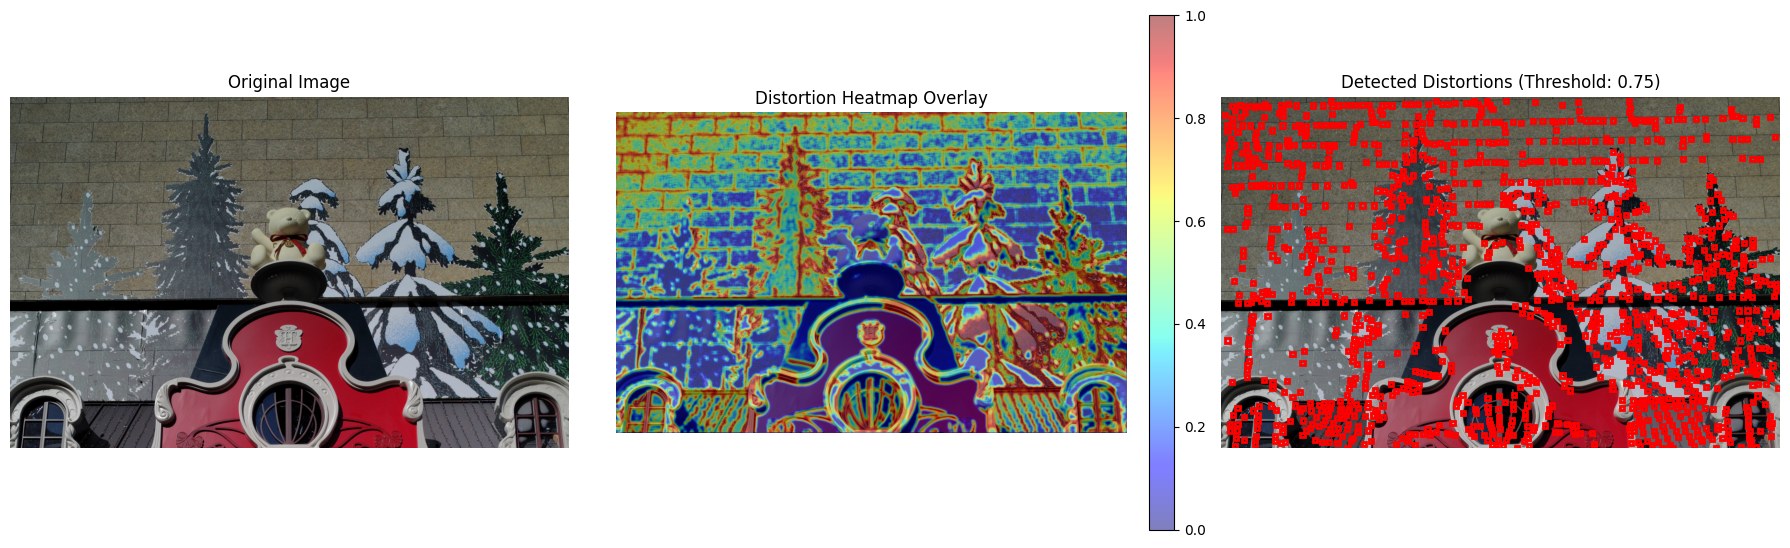

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------------------------------------------------
# Plot 1: The Original Image
# ---------------------------------------------------------
axes[0].imshow(large_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

# ---------------------------------------------------------
# Plot 2: The Heatmap Overlay
# ---------------------------------------------------------
axes[1].imshow(large_img)
# Overlay the heatmap on top of the image using a colormap and 50% transparency
im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Distortion Heatmap Overlay")
axes[1].axis('off')
# Add a colorbar so you know what probabilities the colors represent
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# ---------------------------------------------------------
# Plot 3: Bounding Boxes from NMS
# ---------------------------------------------------------
axes[2].imshow(large_img)
axes[2].set_title(f"Detected Distortions (Threshold: 0.75)")
axes[2].axis('off')

# Loop through the peak coordinates and draw 50x50 boxes
patch_size = 50
for y, x in peak_coords:
    # Matplotlib Rectangle takes (x, y) of the top-left corner, plus width and height
    rect = patches.Rectangle(
        (x, y),
        patch_size,
        patch_size,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    axes[2].add_patch(rect)

plt.tight_layout()
plt.show() # This is the command that actually forces the window to pop up!